Khai báo thư viện và Load dữ liệu

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree, DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, 
                             mean_squared_error, mean_absolute_error, r2_score,
                             precision_score, recall_score, f1_score) # Đã thêm các chỉ số mới

# Cấu hình biểu đồ
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_theme(style="whitegrid")

# Đọc dữ liệu
df_review = pd.read_csv('../data/processed/CAR.csv')

Tiền xử lý dữ liệu (Preprocessing)

In [2]:
# Làm sạch và chuẩn bị biến mục tiêu
df_review = df_review.dropna(subset=['Rating'])
df_review['Class'] = df_review['Class'].fillna(df_review['Class'].mode()[0])
df_review['Traveller_type'] = df_review['Traveller_type'].fillna(df_review['Traveller_type'].mode()[0])

# Tạo biến nhị phân cho Phân loại (Is_Satisfied: Rating >= 6)
df_review['Is_Satisfied'] = (df_review['Rating'] >= 6).astype(int)

# One-hot encoding
df_ml = pd.get_dummies(df_review.drop(columns=['Passanger_Name', 'Review_title', 'Review_content', 'Aircraft', 'Flying_month', 'Route']), 
                       columns=['Class', 'Traveller_type', 'Verified'], drop_first=True)

print("Dữ liệu đã sẵn sàng cho tất cả các kỹ thuật thống kê và ML!")

Dữ liệu đã sẵn sàng cho tất cả các kỹ thuật thống kê và ML!


Thống kê ANOVA & Chi-Square

--- KIỂM ĐỊNH THỐNG KÊ ---
ANOVA: F=34.0192, p=2.3152e-15
Chi-Square: Chi2=122.9799, p=1.7604e-26


C:\Users\ACER\AppData\Local\Temp\ipykernel_17868\178787158.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y='Rating', data=df_review, palette='Set2')


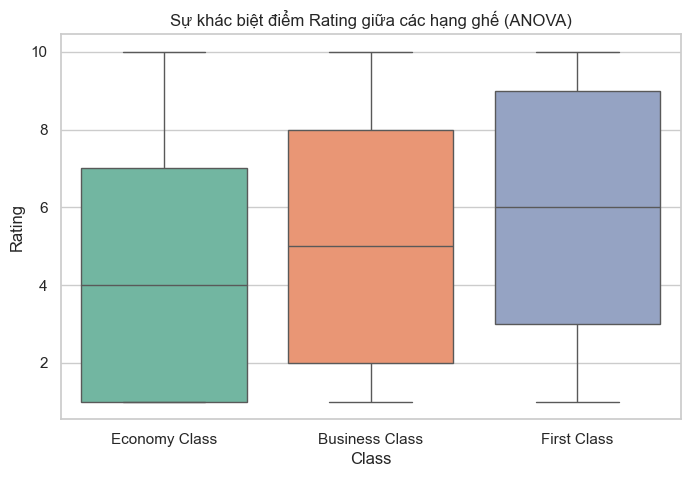

In [3]:
print("--- KIỂM ĐỊNH THỐNG KÊ ---")
# 1. ANOVA
groups = [df_review[df_review['Class'] == c]['Rating'] for c in df_review['Class'].unique()]
f_stat, p_anova = stats.f_oneway(*groups)
print(f"ANOVA: F={f_stat:.4f}, p={p_anova:.4e}")

# 2. Chi-Square
contingency = pd.crosstab(df_review['Traveller_type'], df_review['Is_Satisfied'])
chi2, p_chi2, _, _ = stats.chi2_contingency(contingency)
print(f"Chi-Square: Chi2={chi2:.4f}, p={p_chi2:.4e}")

# Biểu đồ ANOVA cho Slide
plt.figure(figsize=(8, 5))
sns.boxplot(x='Class', y='Rating', data=df_review, palette='Set2')
plt.title('Sự khác biệt điểm Rating giữa các hạng ghế (ANOVA)')
plt.savefig('anova_boxplot.png', dpi=300)
plt.show()

Hồi quy tuyến tính & Biểu đồ trọng số

=== CHỈ SỐ ĐÁNH GIÁ LINEAR REGRESSION ===
1. R-squared (R2 - Độ phù hợp): 0.1071
2. MAE (Sai số tuyệt đối trung bình): 2.6765
3. MSE (Sai số toàn phương trung bình): 9.3161
4. RMSE (Căn bậc 2 của MSE): 3.0522


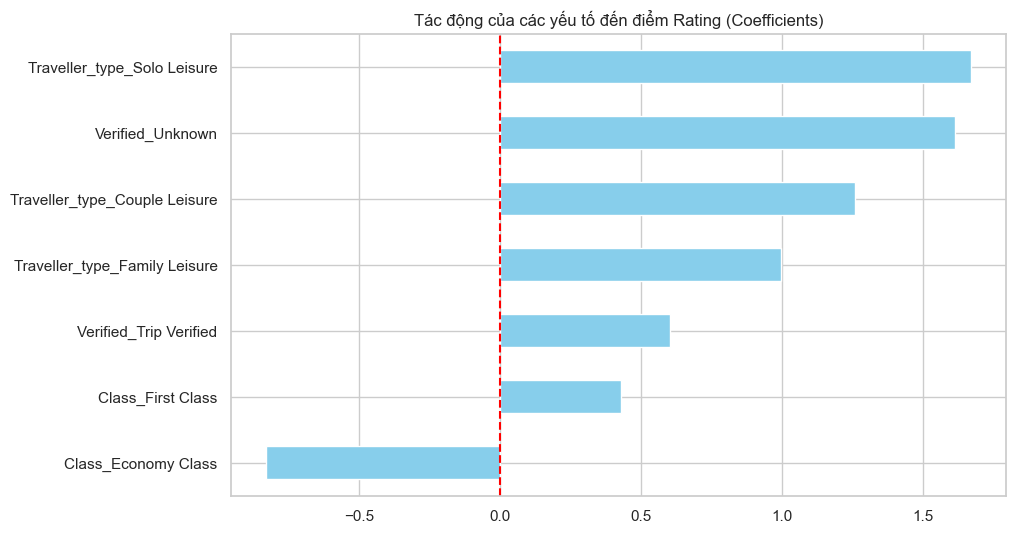

In [ ]:
X_reg = df_ml.drop(columns=['Rating', 'Is_Satisfied'])
y_reg = df_ml['Rating']
X_t_r, X_v_r, y_t_r, y_v_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

lin_reg = LinearRegression().fit(X_t_r, y_t_r)
y_p_r = lin_reg.predict(X_v_r)

print("=== CHỈ SỐ ĐÁNH GIÁ LINEAR REGRESSION ===")
print(f"1. R-squared (R2 - Độ phù hợp): {r2_score(y_v_r, y_p_r):.4f}")
print(f"2. MAE (Sai số tuyệt đối trung bình): {mean_absolute_error(y_v_r, y_p_r):.4f}")
print(f"3. MSE (Sai số toàn phương trung bình): {mean_squared_error(y_v_r, y_p_r):.4f}")
print(f"4. RMSE (Căn bậc 2 của MSE): {np.sqrt(mean_squared_error(y_v_r, y_p_r)):.4f}")

# Ma trận Actual vs Predicted
compare_df = pd.DataFrame({
    'Actual_Rating': y_v_r.reset_index(drop=True),
    'Predicted_Rating': y_p_r
})
compare_df['Absolute_Error'] = (compare_df['Actual_Rating'] - compare_df['Predicted_Rating']).abs()
print("\n=== Ma trận so sánh Actual vs Predicted (20 dòng đầu) ===")
print(compare_df.head(20).to_string(index=False))

# So sánh hiệu suất giữa các thuật toán Regression khác nhau
print("\n=== So sánh thuật toán Regression ===")
dt_reg = DecisionTreeRegressor(max_depth=5, random_state=42).fit(X_t_r, y_t_r)
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42).fit(X_t_r, y_t_r)
y_p_dt_reg = dt_reg.predict(X_v_r)
y_p_rf = rf_reg.predict(X_v_r)

results_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree Regressor', 'Random Forest Regressor'],
    'R2': [
        r2_score(y_v_r, y_p_r),
        r2_score(y_v_r, y_p_dt_reg),
        r2_score(y_v_r, y_p_rf)
    ],
    'MAE': [
        mean_absolute_error(y_v_r, y_p_r),
        mean_absolute_error(y_v_r, y_p_dt_reg),
        mean_absolute_error(y_v_r, y_p_rf)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_v_r, y_p_r)),
        np.sqrt(mean_squared_error(y_v_r, y_p_dt_reg)),
        np.sqrt(mean_squared_error(y_v_r, y_p_rf))
    ]
})
print(results_df.to_string(index=False))

# Vẽ biểu đồ so sánh thuật toán
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(x='R2', y='Model', data=results_df, palette='viridis', ax=axes[0])
axes[0].set_title('So sánh R2 giữa các thuật toán')
axes[0].set_xlabel('R2')
axes[0].set_ylabel('Thuật toán')

sns.barplot(x='MAE', y='Model', data=results_df, palette='magma', ax=axes[1])
axes[1].set_title('So sánh MAE giữa các thuật toán')
axes[1].set_xlabel('MAE')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('regression_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Vẽ scatter Actual vs Predicted cho Linear Regression
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_v_r, y=y_p_r, alpha=0.6)
plt.plot([y_v_r.min(), y_v_r.max()], [y_v_r.min(), y_v_r.max()], color='red', linestyle='--')
plt.title('Actual vs Predicted – Linear Regression')
plt.xlabel('Actual Rating')
plt.ylabel('Predicted Rating')
plt.savefig('linear_actual_vs_predicted.png', dpi=300, bbox_inches='tight')
plt.show()

# Vẽ biểu đồ Trọng số cho Slide
coefs = pd.Series(lin_reg.coef_, index=X_reg.columns).sort_values()
coefs.plot(kind='barh', color='skyblue')
plt.title('Tác động của các yếu tố đến điểm Rating (Coefficients)')
plt.axvline(x=0, color='red', linestyle='--')
plt.savefig('linear_coefficients.png', dpi=300, bbox_inches='tight')
plt.show()


Logistic Regression & Ma trận nhầm lẫn

=== CHỈ SỐ ĐÁNH GIÁ LOGISTIC REGRESSION ===
1. Accuracy  (Độ chính xác tổng thể): 0.6252
2. Precision (Độ chuẩn xác - đoán Hài lòng đúng bao nhiêu %): 0.5612
3. Recall    (Độ phủ - bắt được bao nhiêu % khách Hài lòng thực sự): 0.2737
4. F1-Score  (Trung bình điều hòa của Precision & Recall): 0.3679


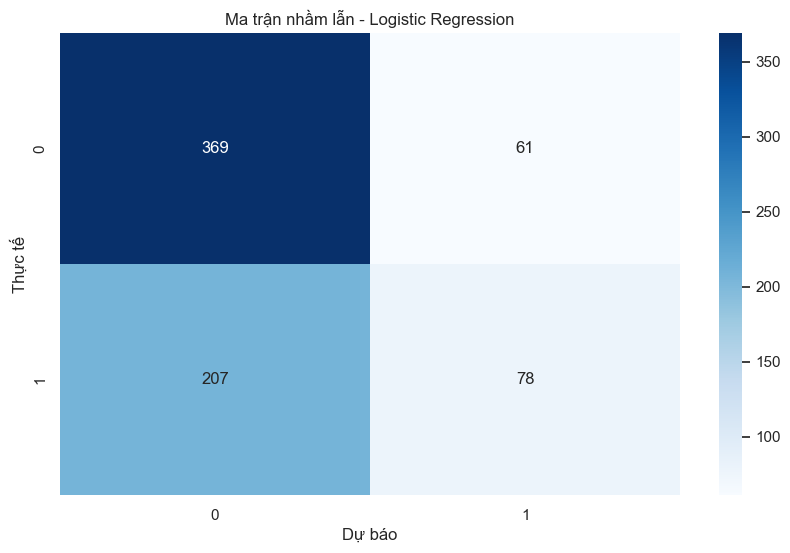

In [5]:
X_clf = df_ml.drop(columns=['Rating', 'Is_Satisfied'])
y_clf = df_ml['Is_Satisfied']
X_t_c, X_v_c, y_t_c, y_v_c = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42)

log_reg = LogisticRegression(max_iter=1000).fit(X_t_c, y_t_c)
y_p_log = log_reg.predict(X_v_c)

print("=== CHỈ SỐ ĐÁNH GIÁ LOGISTIC REGRESSION ===")
print(f"1. Accuracy  (Độ chính xác tổng thể): {accuracy_score(y_v_c, y_p_log):.4f}")
print(f"2. Precision (Độ chuẩn xác - đoán Hài lòng đúng bao nhiêu %): {precision_score(y_v_c, y_p_log, zero_division=0):.4f}")
print(f"3. Recall    (Độ phủ - bắt được bao nhiêu % khách Hài lòng thực sự): {recall_score(y_v_c, y_p_log, zero_division=0):.4f}")
print(f"4. F1-Score  (Trung bình điều hòa của Precision & Recall): {f1_score(y_v_c, y_p_log, zero_division=0):.4f}")

# Vẽ Confusion Matrix cho Slide
cm = confusion_matrix(y_v_c, y_p_log)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Ma trận nhầm lẫn - Logistic Regression')
plt.ylabel('Thực tế')
plt.xlabel('Dự báo')
plt.savefig('logistic_confusion_matrix.png', dpi=300)
plt.show()

Decision Tree & Vẽ cây quyết định
Python

=== CHỈ SỐ ĐÁNH GIÁ DECISION TREE ===
1. Accuracy  (Độ chính xác tổng thể): 0.6336
2. Precision (Độ chuẩn xác): 0.5839
3. Recall    (Độ phủ): 0.2807
4. F1-Score  (Trung bình điều hòa): 0.3791


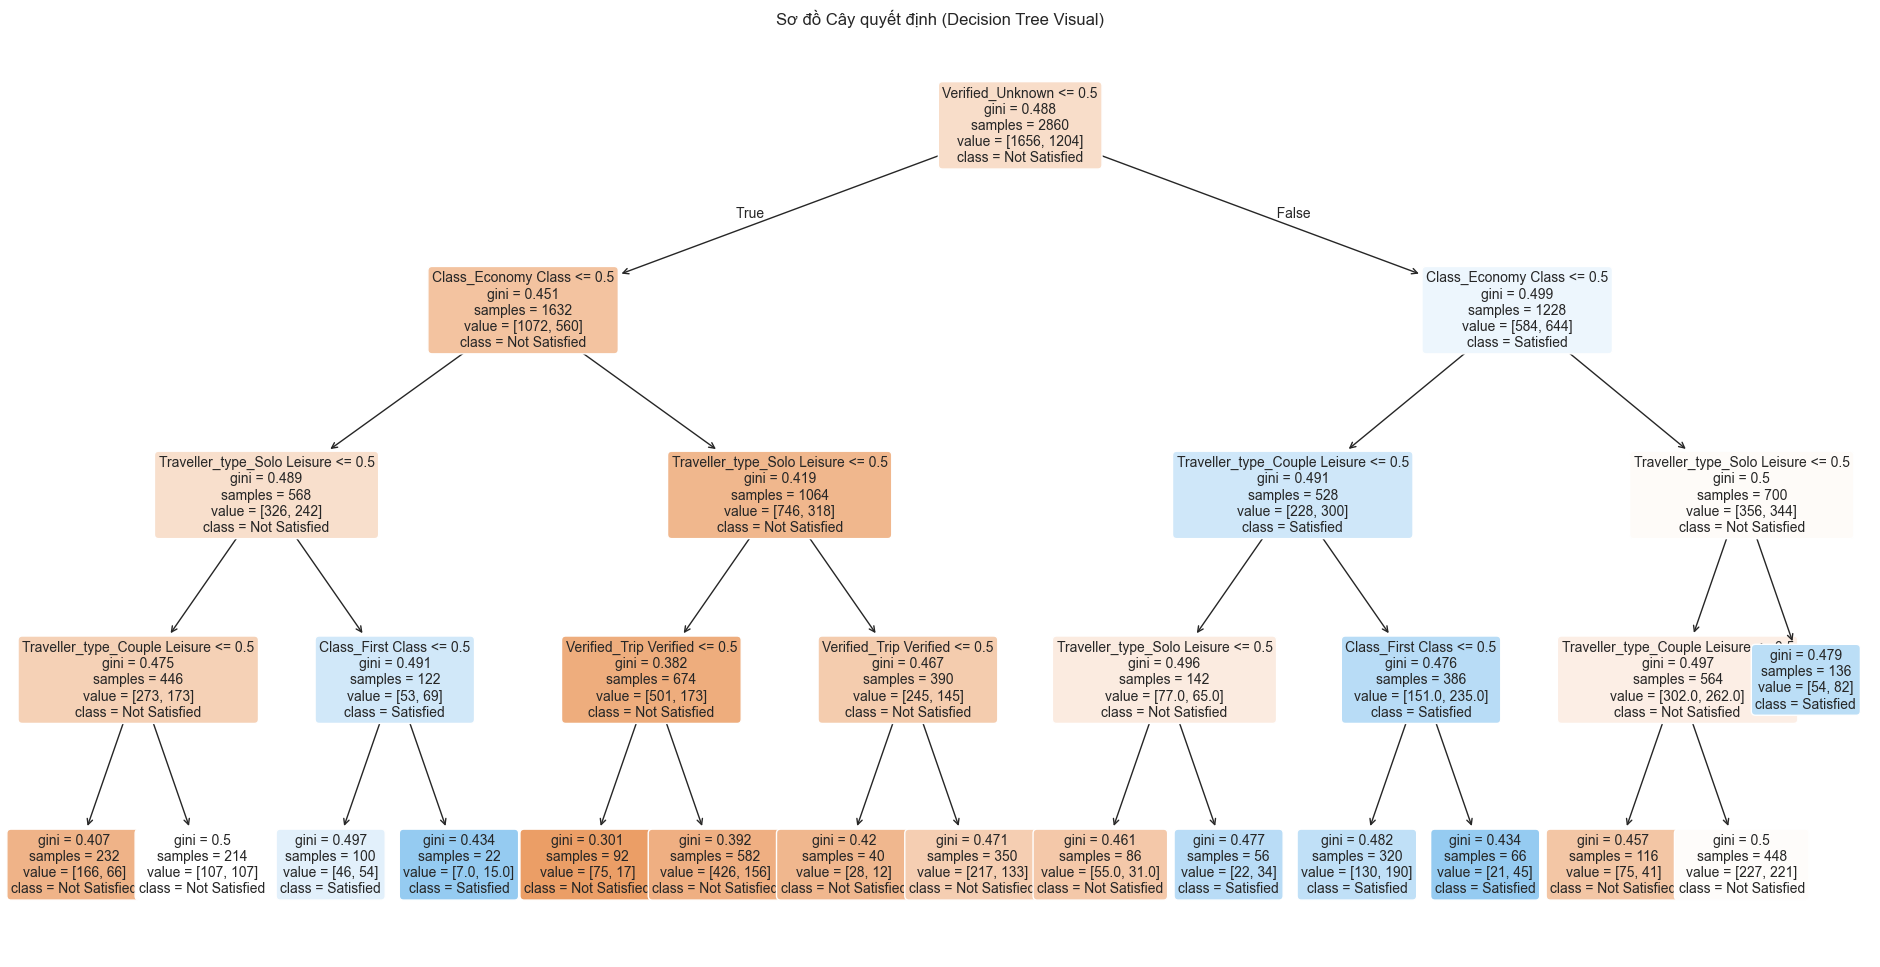

In [6]:
dtree = DecisionTreeClassifier(max_depth=4, random_state=42).fit(X_t_c, y_t_c)
y_p_dt = dtree.predict(X_v_c)

print("=== CHỈ SỐ ĐÁNH GIÁ DECISION TREE ===")
print(f"1. Accuracy  (Độ chính xác tổng thể): {accuracy_score(y_v_c, y_p_dt):.4f}")
print(f"2. Precision (Độ chuẩn xác): {precision_score(y_v_c, y_p_dt, zero_division=0):.4f}")
print(f"3. Recall    (Độ phủ): {recall_score(y_v_c, y_p_dt, zero_division=0):.4f}")
print(f"4. F1-Score  (Trung bình điều hòa): {f1_score(y_v_c, y_p_dt, zero_division=0):.4f}")

# Vẽ Cây cho Slide
plt.figure(figsize=(24, 12)) # Phóng to biểu đồ cây để xem cho rõ
plot_tree(dtree, feature_names=X_clf.columns, class_names=['Not Satisfied', 'Satisfied'], 
          filled=True, rounded=True, fontsize=10)
plt.title('Sơ đồ Cây quyết định (Decision Tree Visual)')
plt.savefig('decision_tree_graph.png', dpi=300, bbox_inches='tight')
plt.show()

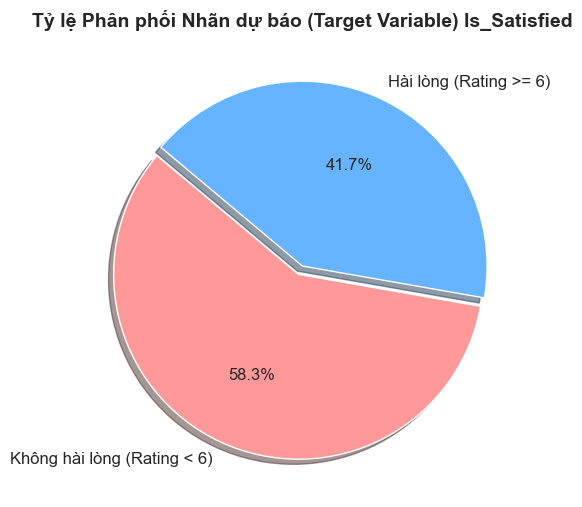

In [7]:
import matplotlib.pyplot as plt

# Biểu đồ tỷ lệ Trạng thái hài lòng
satisfaction_counts = df_review['Is_Satisfied'].value_counts()
labels = ['Không hài lòng (Rating < 6)', 'Hài lòng (Rating >= 6)']
colors = ['#ff9999','#66b3ff']
explode = (0.05, 0) # Tách một mảnh ra cho nổi bật

plt.figure(figsize=(7, 6))
plt.pie(satisfaction_counts, explode=explode, labels=labels, colors=colors, 
        autopct='%1.1f%%', shadow=True, startangle=140, textprops={'fontsize': 12})
plt.title('Tỷ lệ Phân phối Nhãn dự báo (Target Variable) Is_Satisfied', fontsize=14, fontweight='bold')
plt.savefig('target_distribution.png', dpi=300)
plt.show()

In [ ]:
# Đánh giá hành vi khách hàng bằng các chỉ số phân loại
print("=== ĐÁNH GIÁ HÀNH VI KHÁCH HÀNG ===")
print(f"Accuracy  : {accuracy_score(y_v_c, y_p_dt):.4f}")
print(f"Precision : {precision_score(y_v_c, y_p_dt, zero_division=0):.4f}")
print(f"Recall    : {recall_score(y_v_c, y_p_dt, zero_division=0):.4f}")
print(f"F1-Score  : {f1_score(y_v_c, y_p_dt, zero_division=0):.4f}")

# In thêm báo cáo phân loại để hiểu rõ hơn hành vi khách hàng theo nhãn
print("\nClassification Report:")
print(classification_report(y_v_c, y_p_dt, target_names=['Không hài lòng', 'Hài lòng'], zero_division=0))

In [8]:
import pandas as pd

# Tính toán số lượng và tỷ lệ khuyết thiếu ban đầu
missing_data = pd.DataFrame({
    'Số lượng NaN ban đầu': df_review.isnull().sum(),
    'Tỷ lệ khuyết (%)': (df_review.isnull().mean() * 100).round(2)
})

# Chỉ hiển thị các cột có dữ liệu bị khuyết
missing_data = missing_data[missing_data['Số lượng NaN ban đầu'] > 0]
print("=== THỐNG KÊ DỮ LIỆU KHUYẾT THIẾU BAN ĐẦU ===")
print(missing_data)

=== THỐNG KÊ DỮ LIỆU KHUYẾT THIẾU BAN ĐẦU ===
              Số lượng NaN ban đầu  Tỷ lệ khuyết (%)
Flying_month                  2619             73.26
Route                          780             21.82
Aircraft                      1733             48.48
